In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mltools as ml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
red_wine = pd.read_csv("wine+quality/winequality-red.csv", delimiter=";")
white_wine = pd.read_csv("wine+quality/winequality-white.csv", delimiter=";")

In [3]:
print(red_wine.shape)
print(white_wine.shape)

(1599, 12)
(4898, 12)


In [4]:
red_wine["wine_type"] = 0
white_wine["wine_type"] = 1

In [5]:
#combining wines
wine_data = pd.concat([red_wine, white_wine], axis=0)

# Check dataset information
print(wine_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 710.6 KB
None


In [6]:
print(wine_data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  wine_type  
0      9.4        5          0  
1      9.8        5 

In [7]:
# Get summary statistics grouped by wine type
summary_stats = wine_data.groupby("wine_type").describe()
print(summary_stats)


          fixed acidity                                                \
                  count      mean       std  min  25%  50%  75%   max   
wine_type                                                               
0                1599.0  8.319637  1.741096  4.6  7.1  7.9  9.2  15.9   
1                4898.0  6.854788  0.843868  3.8  6.3  6.8  7.3  14.2   

          volatile acidity            ... alcohol       quality            \
                     count      mean  ...     75%   max   count      mean   
wine_type                             ...                                   
0                   1599.0  0.527821  ...    11.1  14.9  1599.0  5.636023   
1                   4898.0  0.278241  ...    11.4  14.2  4898.0  5.877909   

                                              
                std  min  25%  50%  75%  max  
wine_type                                     
0          0.807569  3.0  5.0  6.0  6.0  8.0  
1          0.885639  3.0  5.0  6.0  6.0  9.0  

[2 rows x 96

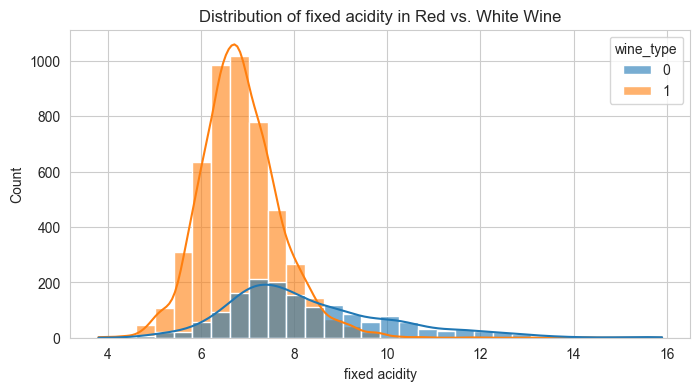

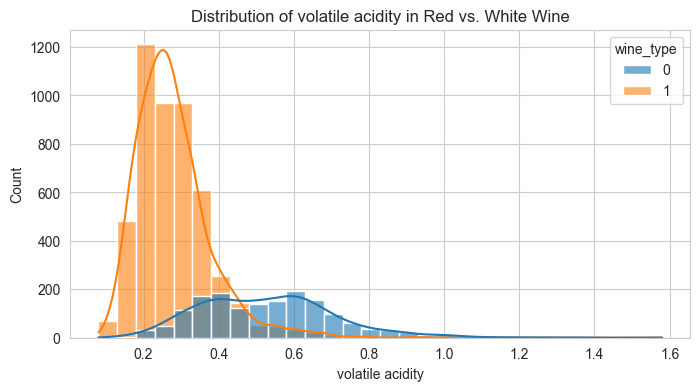

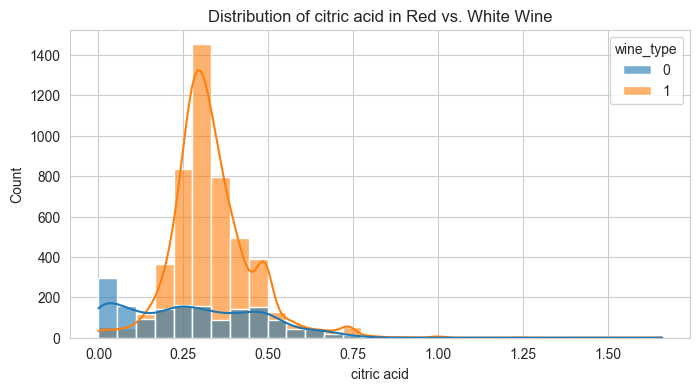

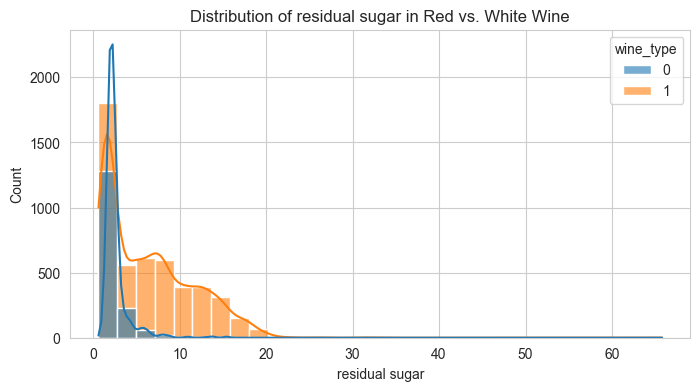

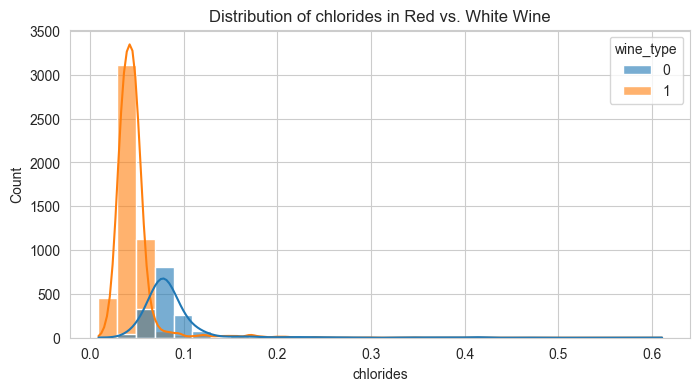

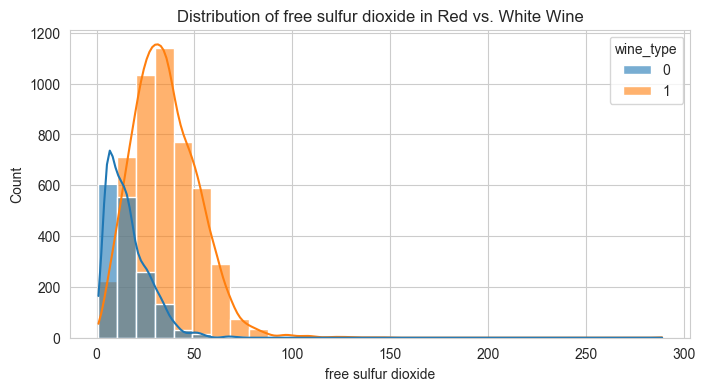

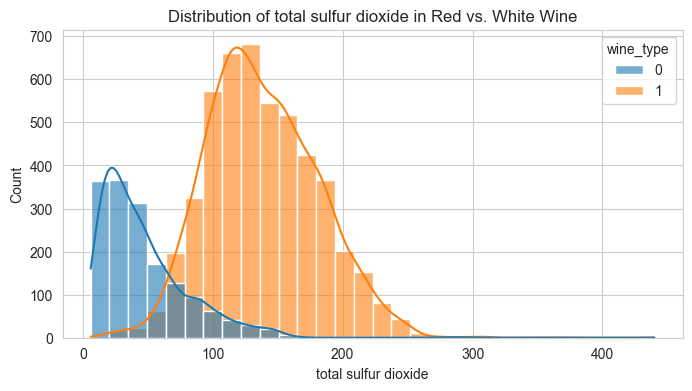

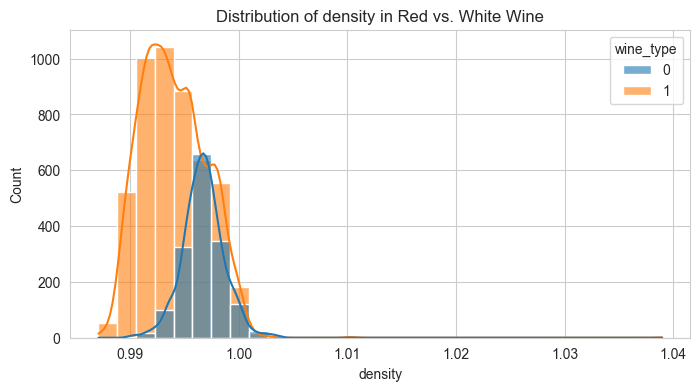

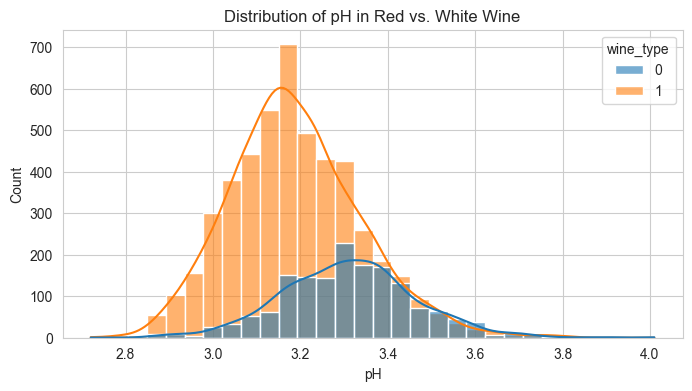

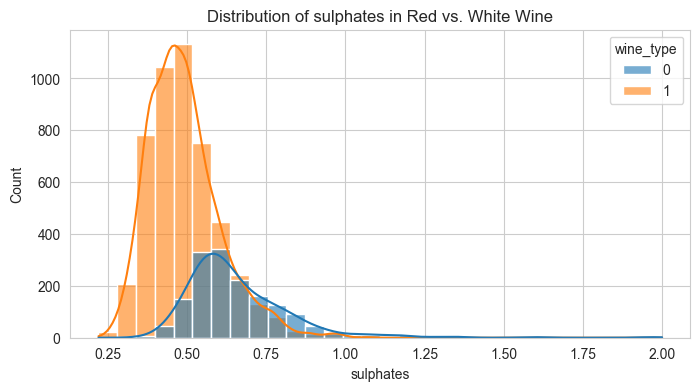

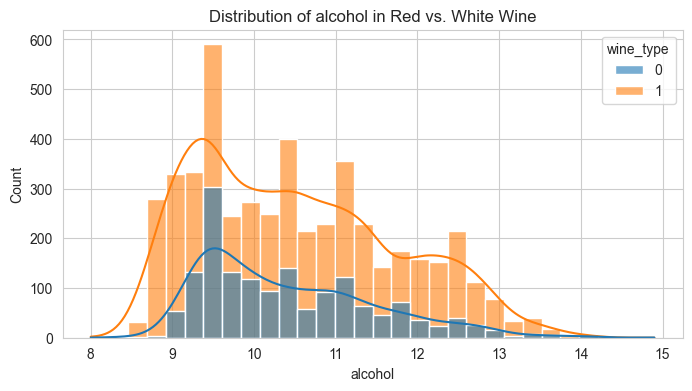

In [8]:
sns.set_style("whitegrid")

# Plot histograms for key features
features = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide", "density","pH","sulphates", "alcohol"]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=wine_data, x=feature, hue="wine_type", kde=True, bins=30, alpha=0.6)
    plt.title(f"Distribution of {feature} in Red vs. White Wine")
    plt.show()


In [9]:
wine_data.groupby("wine_type")[features].describe().T

wine_type                      0            1
fixed acidity count  1599.000000  4898.000000
              mean      8.319637     6.854788
              std       1.741096     0.843868
              min       4.600000     3.800000
              25%       7.100000     6.300000
...                          ...          ...
alcohol       min       8.400000     8.000000
              25%       9.500000     9.500000
              50%      10.200000    10.400000
              75%      11.100000    11.400000
              max      14.900000    14.200000

[88 rows x 2 columns]

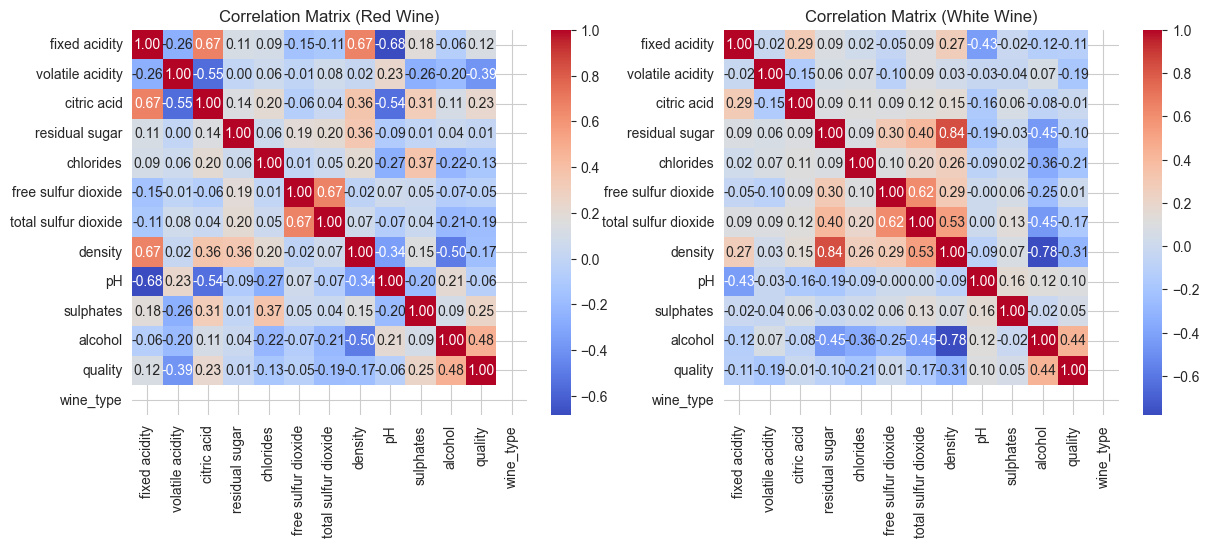

In [10]:
# Compute correlation matrices separately for red and white wines
corr_red = red_wine.corr()
corr_white = white_wine.corr()

# Plot heatmaps
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_red, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Correlation Matrix (Red Wine)")
sns.heatmap(corr_white, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[1])
ax[1].set_title("Correlation Matrix (White Wine)")
plt.show()


Alcohol has the highest positive relationship with the quality in red wine. The feature volatile acidity has the highest negative relationship with the wine quality. The weakest relationships are the residual sugar, free sulfur dioxide, and pH. 

For white wine, sulphates, pH, free sulfur dioxide, and citric acid have weak relationships with quality. 

Maybe we should keep two different models for white and red because the of difference in the distributions and correlations. 

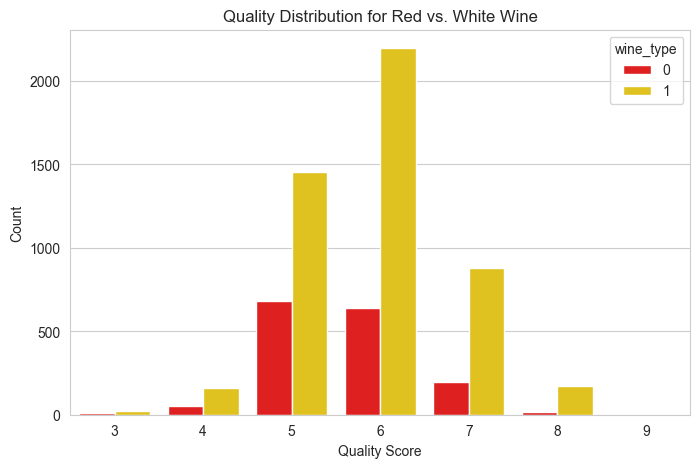

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=wine_data, x="quality", hue="wine_type", palette=["red", "gold"])
plt.title("Quality Distribution for Red vs. White Wine")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()


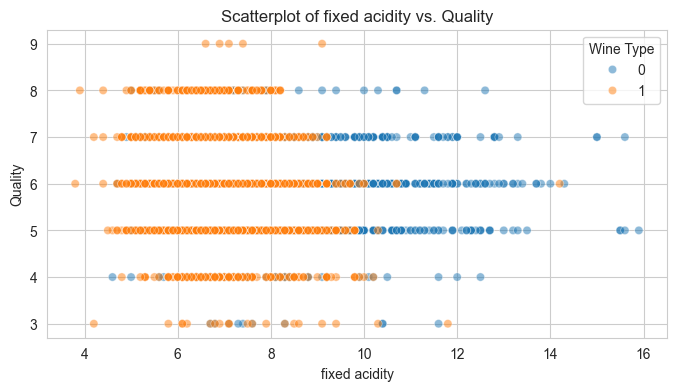

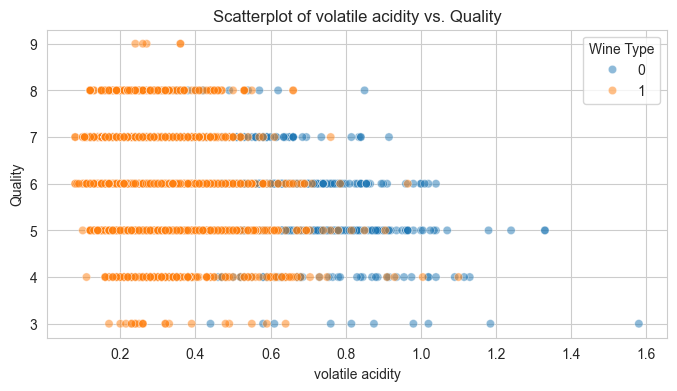

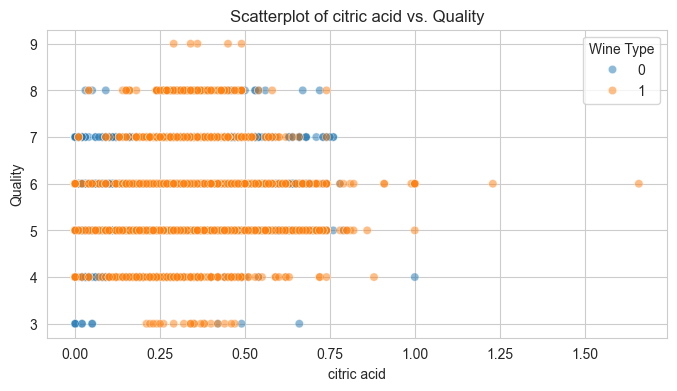

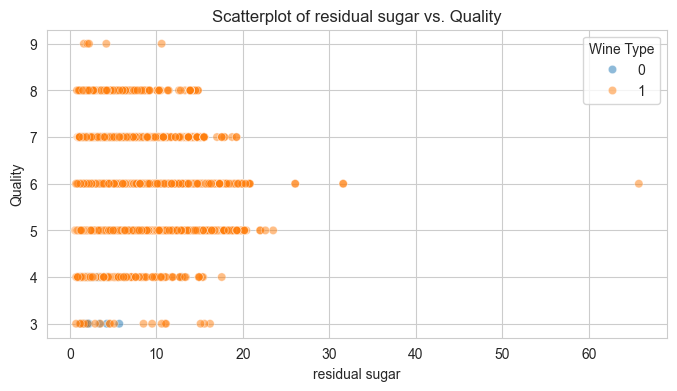

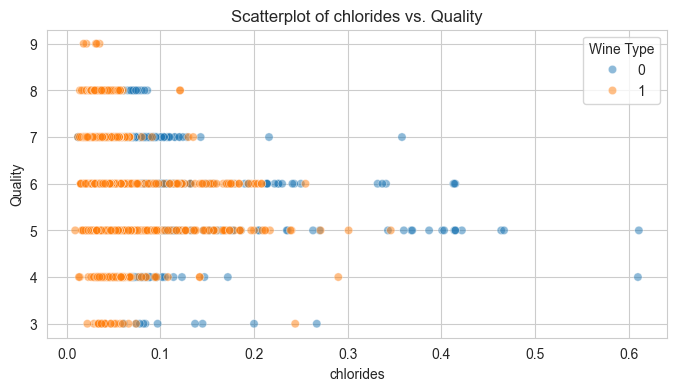

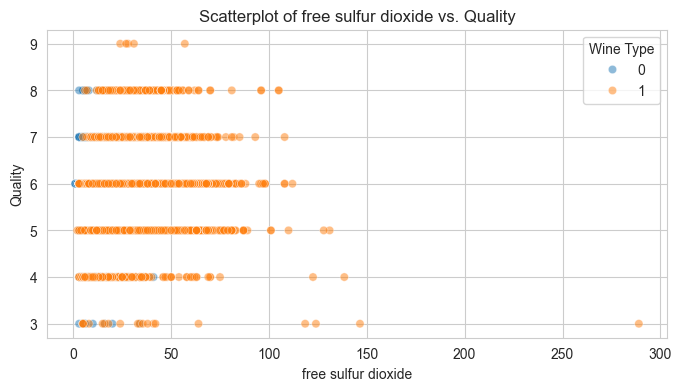

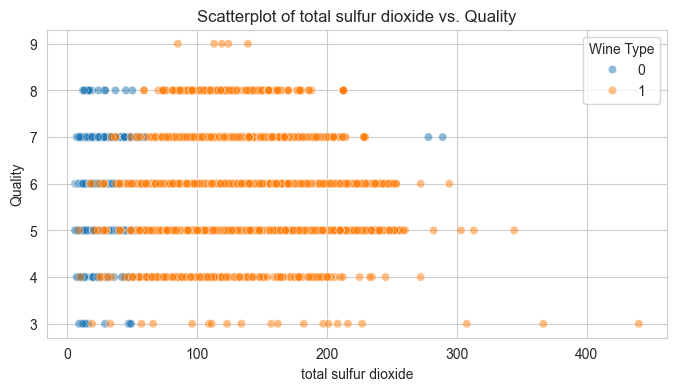

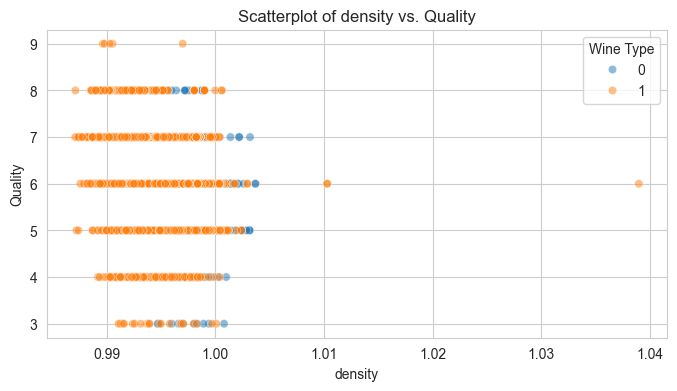

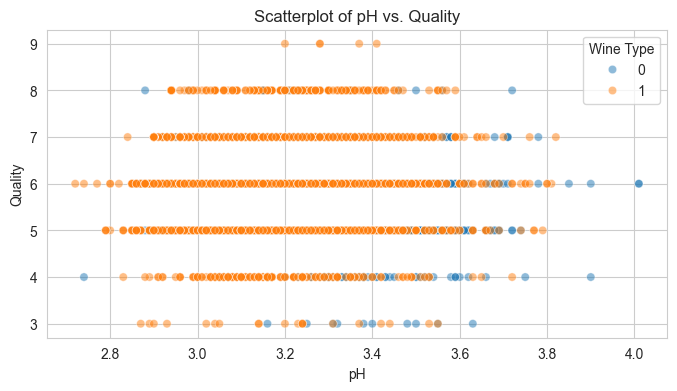

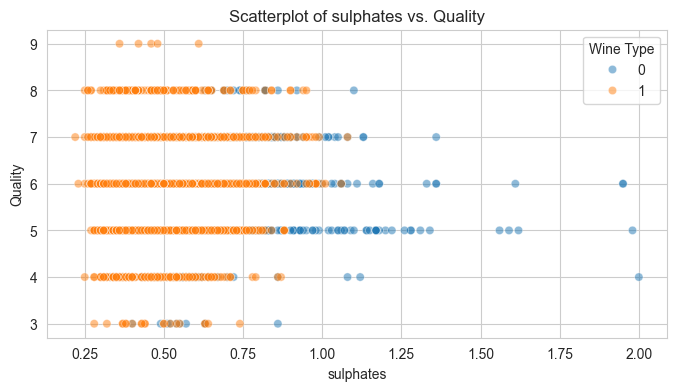

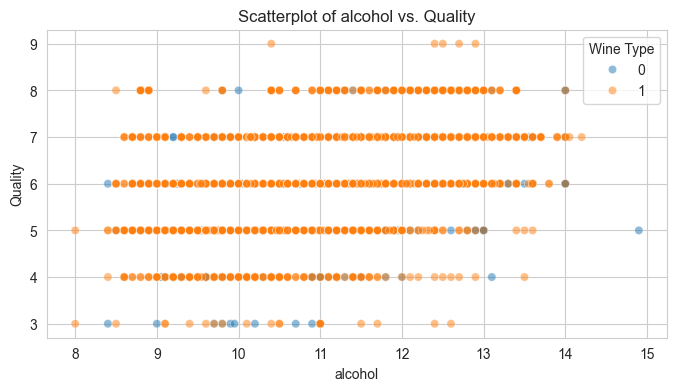

In [12]:

# List of features to test for linearity
features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides",
    "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"
]

# Plot scatterplots of each feature against quality
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=wine_data, x=feature, y="quality", hue="wine_type", alpha=0.5)
    plt.title(f"Scatterplot of {feature} vs. Quality")
    plt.xlabel(feature)
    plt.ylabel("Quality")
    plt.legend(title="Wine Type")
    plt.show()


## Feature Selection

In [13]:
#wine_data['wine_type_chlorides'] = wine_data['wine_type'] * wine_data['chlorides']
#wine_data['alcohol_sulphates'] = wine_data['alcohol'] * wine_data['sulphates'] # domain knowledge 
#wine_data['wine_type_density'] = wine_data['wine_type'] * wine_data['density']
#wine_data['wine_type_volatileacidity'] = wine_data['wine_type'] * wine_data['volatile acidity']

X = wine_data.drop(['total sulfur dioxide','quality'], axis=1)
Y = wine_data['quality']

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

# Step 2: Split the temporary set into validation (50%) and test (50%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)


X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
X_val = X_val.to_numpy()
Y_val = Y_val.to_numpy()
Y_train  = Y_train.to_numpy()
Y_test = Y_test.to_numpy()
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"Y_val shape: {Y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")


X_train shape: (4547, 11)
Y_train shape: (4547,)
X_val shape: (975, 11)
Y_val shape: (975,)
X_test shape: (975, 11)
Y_test shape: (975,)


## Gradient Boosting

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Define the model
model = GradientBoostingRegressor(random_state=42)

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train, Y_train, scoring='neg_mean_squared_error', cv=5)
mse_scores = -scores
print(f"Cross-Validation MSE: {mse_scores.mean():.4f} (±{mse_scores.std():.4f})")

# Perform grid search for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(model, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, Y_train)

# Print the best parameters
print(f"Best parameters: {grid_search.best_params_}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
Y_pred = best_model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
r2 = r2_score(Y_test, Y_pred)
print(f"Test MSE with best model: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Cross-Validation MSE: 0.4845 (±0.0391)
Best parameters: {'learning_rate': 0.05, 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}


NameError: name 'ypred' is not defined

In [15]:
# Print the best parameters
print(f"Best parameters: {grid_search.best_params_}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
Y_pred = best_model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
r2 = r2_score(Y_test, Y_pred)

print(f"Test MSE with best model: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Best parameters: {'learning_rate': 0.05, 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}
Test MSE with best model: 0.3443
RMSE: 0.5868
R-squared: 0.5187


Boosting Stage 10: Train MSE = 0.4638, Val MSE = 0.5522
Boosting Stage 20: Train MSE = 0.3199, Val MSE = 0.4787
Boosting Stage 30: Train MSE = 0.2389, Val MSE = 0.4450
Boosting Stage 40: Train MSE = 0.1941, Val MSE = 0.4338
Boosting Stage 50: Train MSE = 0.1641, Val MSE = 0.4270
Boosting Stage 60: Train MSE = 0.1433, Val MSE = 0.4198
Boosting Stage 70: Train MSE = 0.1271, Val MSE = 0.4116
Boosting Stage 80: Train MSE = 0.1088, Val MSE = 0.4115
Boosting Stage 90: Train MSE = 0.1021, Val MSE = 0.4081
Boosting Stage 100: Train MSE = 0.1002, Val MSE = 0.4072
Boosting Stage 110: Train MSE = 0.0874, Val MSE = 0.4052
Boosting Stage 120: Train MSE = 0.0895, Val MSE = 0.4024
Boosting Stage 130: Train MSE = 0.0815, Val MSE = 0.4003
Boosting Stage 140: Train MSE = 0.0785, Val MSE = 0.3991
Boosting Stage 150: Train MSE = 0.0765, Val MSE = 0.4041
Boosting Stage 160: Train MSE = 0.0710, Val MSE = 0.4015
Boosting Stage 170: Train MSE = 0.0639, Val MSE = 0.3948
Boosting Stage 180: Train MSE = 0.0577, 

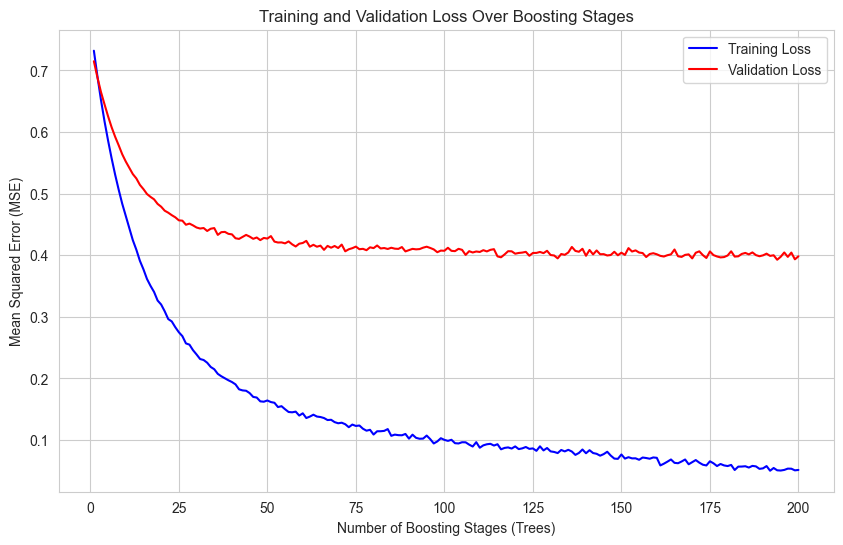

In [16]:

# Initialize the model
model = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=9,
    min_samples_leaf = 4, 
    min_samples_split = 2 
)

# Number of boosting stages (trees)
n_estimators = 200

# Lists to store training and validation loss
train_loss = []
val_loss = []

# Train incrementally and track loss
for i in range(1, n_estimators + 1):
    model.set_params(n_estimators=i)
    model.fit(X_train, Y_train)

    # Predict on training and validation sets
    Y_train_pred = model.predict(X_train)
    Y_val_pred = model.predict(X_val)

    # Calculate Mean Squared Error (MSE)
    train_mse = mean_squared_error(Y_train, Y_train_pred)
    val_mse = mean_squared_error(Y_val, Y_val_pred)

    # Store the loss values
    train_loss.append(train_mse)
    val_loss.append(val_mse)

    # Print progress
    if i % 10 == 0:
        print(f"Boosting Stage {i}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}")

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_estimators + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, n_estimators + 1), val_loss, label='Validation Loss', color='red')
plt.xlabel('Number of Boosting Stages (Trees)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation Loss Over Boosting Stages')
plt.legend()
plt.grid(True)
plt.show()
